In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 100

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, n),
    "Income": np.random.randint(20000, 100000, n),
    "Purchase_Amount": np.random.randint(500, 5000, n),
    "Savings": np.random.randint(5000, 50000, n),
    "Credit_Score": np.random.randint(300, 850, n)
})

df["Purchased"] = (
    (df["Purchase_Amount"] > 2000) |
    (df["Age"] < 25)
).astype(int)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (100, 6)


,Age,Income,Purchase_Amount,Savings,Credit_Score,Purchased
0,56,28392,646,16093,393,0
1,46,50535,3719,23070,752,1
2,32,98603,3411,40777,503,1
3,25,72256,2234,21538,517,1
4,38,55222,2343,15729,773,1


In [3]:
# Select customer features for clustering
features = [
    "Age",
    "Income",
    "Purchase_Amount",
    "Savings",
    "Credit_Score"
]

X = df[features]

print("Selected Features:", features)
print("Feature Shape:", X.shape)

Selected Features: ['Age', 'Income', 'Purchase_Amount', 'Savings', 'Credit_Score']
Feature Shape: (100, 5)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original Shape:", X.shape)
print("Scaled Shape:", X_scaled.shape)
print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

Original Shape: (100, 5)
Scaled Shape: (100, 5)

First 5 scaled rows:
[[ 1.48788435 -1.49121945 -1.64216295 -0.68028284 -1.11482478]
 [ 0.66539438 -0.50634208  0.7304653  -0.1058651   1.13664966]
 [-0.48609157  1.63162863  0.49266201  1.35195558 -0.42495796]
 [-1.06183455  0.45976556 -0.41608626 -0.23199495 -0.33715673]
 [ 0.00740241 -0.29787348 -0.33192861 -0.71025103  1.26835151]]


In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("Cluster labels:", sorted(df["Cluster"].unique()))
print("\nCustomers in each cluster:")
print(df["Cluster"].value_counts().sort_index())

Cluster labels: [np.int32(0), np.int32(1), np.int32(2)]

Customers in each cluster:
Cluster
0    29
1    43
2    28
Name: count, dtype: int64


In [6]:
cluster_summary = df.groupby("Cluster")[features].mean().round(2)

print("Customer Segment Summary:")
print(cluster_summary)

Customer Segment Summary:
           Age    Income  Purchase_Amount   Savings  Credit_Score
Cluster                                                          
0        29.45  47448.24          3762.97  31857.00        586.45
1        39.19  78063.02          2668.40  23564.47        652.95
2        44.71  52114.29          1908.00  17802.18        428.29


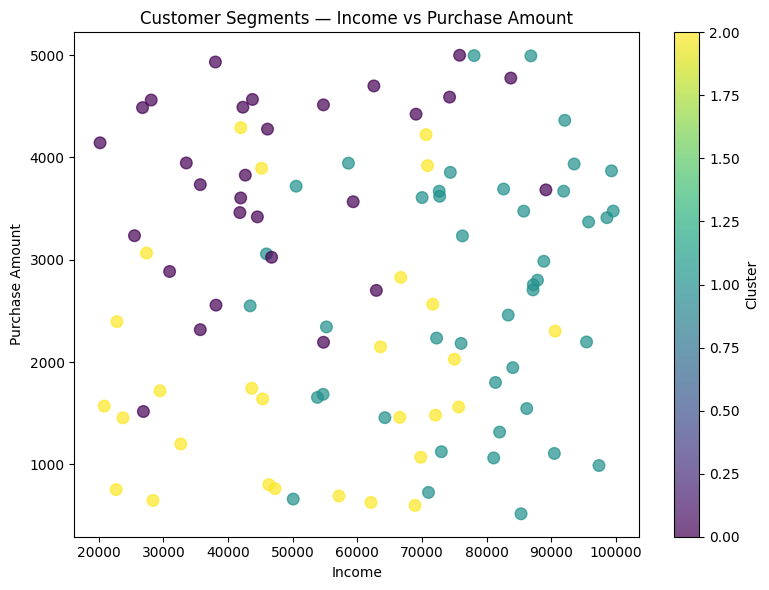

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Income"],
    df["Purchase_Amount"],
    c=df["Cluster"],
    s=70,
    alpha=0.7
)

plt.xlabel("Income")
plt.ylabel("Purchase Amount")
plt.title("Customer Segments — Income vs Purchase Amount")
plt.colorbar(label="Cluster")

plt.tight_layout()
plt.show()

In [8]:
from sklearn.cluster import KMeans

inertia_values = []

for k in range(2, 7):
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans_temp.fit(X_scaled)
    inertia_values.append(kmeans_temp.inertia_)

print("K values:", list(range(2, 7)))
print("Inertia values:", inertia_values)

K values: [2, 3, 4, 5, 6]
Inertia values: [414.9644709620231, 354.0324288549146, 307.60268531420854, 274.3339526845051, 241.18541983816633]


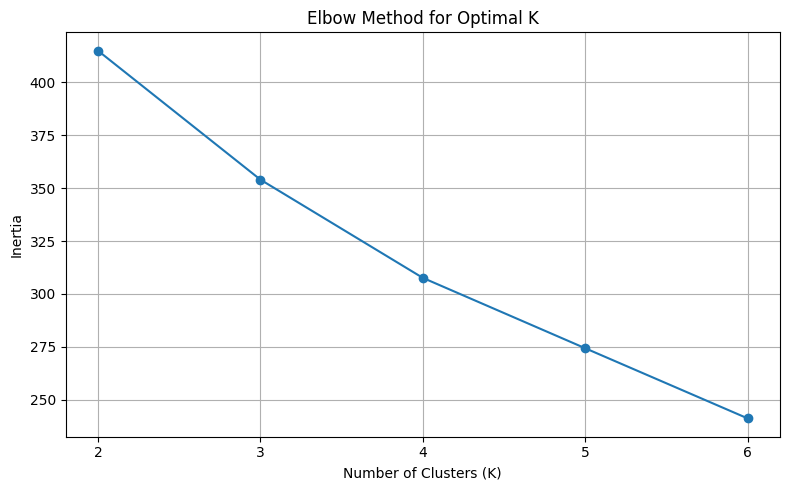

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 7),
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(range(2, 7))
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = final_kmeans.fit_predict(X_scaled)

print("Final K-Means model created.")
print("\nCluster Distribution:")
print(df["Cluster"].value_counts().sort_index())

Final K-Means model created.

Cluster Distribution:
Cluster
0    29
1    43
2    28
Name: count, dtype: int64


In [11]:
cluster_summary = (
    df.groupby("Cluster")
      .agg(
          Customers=("Cluster", "size"),
          Avg_Age=("Age", "mean"),
          Avg_Income=("Income", "mean"),
          Avg_Purchase=("Purchase_Amount", "mean"),
          Avg_Savings=("Savings", "mean"),
          Avg_Credit_Score=("Credit_Score", "mean")
      )
      .round(2)
)

print("Final Customer Segment Analysis:")
display(cluster_summary)

Final Customer Segment Analysis:


,Customers,Avg_Age,Avg_Income,Avg_Purchase,Avg_Savings,Avg_Credit_Score
Cluster,,,,,,
0,29,29.45,47448.24,3762.97,31857.00,586.45
1,43,39.19,78063.02,2668.40,23564.47,652.95
2,28,44.71,52114.29,1908.00,17802.18,428.29


In [13]:
segment_names = {
    0: "Younger High-Spending",
    1: "Higher-Income",
    2: "Older Lower-Spending"
}

df["Segment"] = df["Cluster"].map(segment_names)

print(df[["Cluster", "Segment"]].drop_duplicates().sort_values("Cluster"))

   Cluster                Segment
8        0  Younger High-Spending
1        1          Higher-Income
0        2   Older Lower-Spending


In [14]:
business_report = cluster_summary.copy()

business_report["Segment"] = business_report.index.map(segment_names)

business_report = business_report[
    [
        "Segment",
        "Customers",
        "Avg_Age",
        "Avg_Income",
        "Avg_Purchase",
        "Avg_Savings",
        "Avg_Credit_Score"
    ]
]

business_report.to_csv(
    "day29_business_insight_report.csv",
    index_label="Cluster"
)

print("Business insight report saved successfully.")
display(business_report)

Business insight report saved successfully.


,Segment,Customers,Avg_Age,Avg_Income,Avg_Purchase,Avg_Savings,Avg_Credit_Score
Cluster,,,,,,,
0,Younger High-Spending,29,29.45,47448.24,3762.97,31857.00,586.45
1,Higher-Income,43,39.19,78063.02,2668.40,23564.47,652.95
2,Older Lower-Spending,28,44.71,52114.29,1908.00,17802.18,428.29


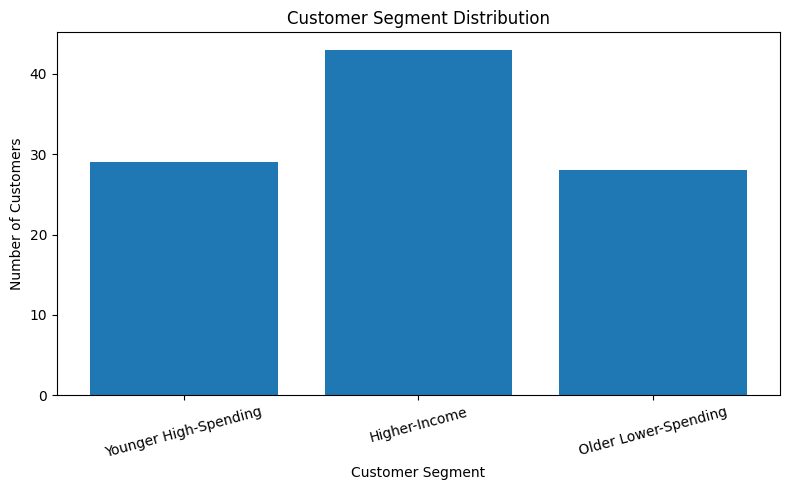

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    business_report["Segment"],
    business_report["Customers"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segment Distribution")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [16]:
print("===== DAY 29 FINAL RESULTS =====")
print("Number of Clusters:", len(df["Cluster"].unique()))
print("Cluster Distribution:")
print(df["Cluster"].value_counts().sort_index())
print("\nBusiness Insight Report:")
display(business_report)
print("\nSaved File: day29_business_insight_report.csv")

===== DAY 29 FINAL RESULTS =====
Number of Clusters: 3
Cluster Distribution:
Cluster
0    29
1    43
2    28
Name: count, dtype: int64

Business Insight Report:


,Segment,Customers,Avg_Age,Avg_Income,Avg_Purchase,Avg_Savings,Avg_Credit_Score
Cluster,,,,,,,
0,Younger High-Spending,29,29.45,47448.24,3762.97,31857.00,586.45
1,Higher-Income,43,39.19,78063.02,2668.40,23564.47,652.95
2,Older Lower-Spending,28,44.71,52114.29,1908.00,17802.18,428.29



Saved File: day29_business_insight_report.csv
